# TakaPay social feed — exploratory analysis

660 social-media posts about the mobile wallet **TakaPay** (June 2026), mixing Bangla, Banglish and English across 7 platforms.

This notebook does two jobs:

1. **Understand the feed** — what people talk about, where, in which language, and how they feel.
2. **Audit the data** — the brief warns the labels aren't all clean. Before any number reaches a dashboard, we verify it. Sections 4–5 find and correct the problems.

**Runs on Kaggle or locally.** On Kaggle, attach the dataset; locally it reads from `../../data/`. The transformer section auto-skips if `transformers` isn't installed — every other section is pure pandas/matplotlib.


In [1]:
import json, os, re, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore")

# ---------- data location (Kaggle or local) ----------
_kaggle = glob.glob("/kaggle/input/**/takapay_sample_data.csv", recursive=True)
DATA_CSV = Path(_kaggle[0]) if _kaggle else Path("../../data/takapay_sample_data.csv")
DATA_JSON = DATA_CSV.with_suffix(".json")
FIG_DIR = Path("../figures") if not _kaggle else Path("figures")
OUT_DIR = Path("../outputs") if not _kaggle else Path("outputs")
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- chart style ----------
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
POS, NEG, NEU = "#2a78d6", "#d03b3b", "#898781"          # sentiment: diverging blue/red + neutral gray
SENT_COLOR = {"positive": POS, "negative": NEG, "neutral": NEU}
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUES = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#256abf", "#184f95"]  # ordinal-safe ramp

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "axes.titlesize": 12.5, "axes.titleweight": "600", "axes.titlepad": 12,
    "figure.dpi": 110,
})

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

def bar_labels(ax, bars, fmt="{:,.0f}", pad=3, color=INK2, fs=9.5):
    for b in bars:
        ax.annotate(fmt.format(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_height()),
                    textcoords="offset points", xytext=(0, pad), ha="center", fontsize=fs, color=color)

print("data:", DATA_CSV.resolve())

data: E:\AI Projects\DeepdiveInsights\data\takapay_sample_data.csv


## 1. Load & verify

Both files claim the same 660 records — trust, but verify.

In [2]:
df = pd.read_csv(DATA_CSV)
with open(DATA_JSON, encoding="utf-8") as f:
    dj = pd.DataFrame(json.load(f))

same = df.sort_values("id").reset_index(drop=True).astype(str).equals(
       dj[df.columns].sort_values("id").reset_index(drop=True).astype(str))
print(f"records: csv={len(df)}, json={len(dj)}, identical={same}")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date
df.head(3)

records: csv=660, json=660, identical=True


,id,platform,timestamp,author,text,language,brand_mention,sentiment,sentiment_score,topic,reactions,comments,date
0,1017,TikTok,2026-06-21 01:16:00,Farhana15,"TakaPay helpline e 30 min wait korlam, keu dho...",bn-en,True,negative,8,customer_care,174,76,2026-06-21
1,1173,TikTok,2026-06-08 23:49:00,Sabbir77,Paid my gas bill on TakaPay in under a minute....,en,True,positive,88,bill_payment,40,106,2026-06-08
2,1043,YouTube,2026-06-25 04:05:00,Tuhin27,Paid my internet bill on TakaPay in under a mi...,en,True,positive,92,bill_payment,148,57,2026-06-25


In [3]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isna().sum(),
    "unique": df.nunique(),
    "example": df.iloc[0].astype(str).str.slice(0, 60),
})
print(summary.to_string())
print(f"\ntime range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"duplicate ids: {df['id'].duplicated().sum()}  |  duplicate texts: {df['text'].duplicated().sum()}")

                          dtype  nulls  unique                                                example
id                        int64      0     660                                                   1017
platform                    str      0       7                                                 TikTok
timestamp        datetime64[us]      0     652                                    2026-06-21 01:16:00
author                      str      0     583                                              Farhana15
text                        str      0     650  TakaPay helpline e 30 min wait korlam, keu dhorlo na.
language                    str      0       3                                                  bn-en
brand_mention              bool      0       1                                                   True
sentiment                   str      0       3                                               negative
sentiment_score           int64      0      64                                    

**So far:** no nulls, no duplicate IDs, one clean month (June 2026). But 10 texts appear twice under different IDs — we'll come back to that in the audit.

## 2. What the feed looks like


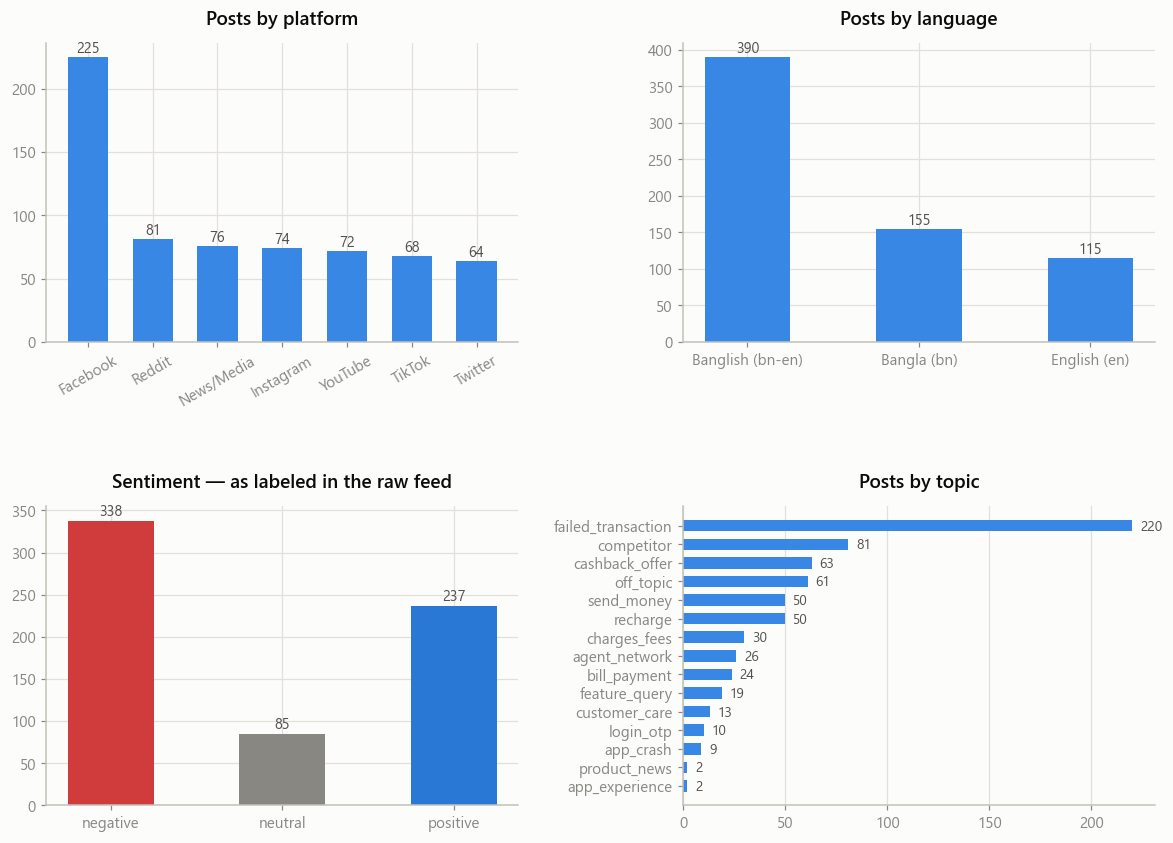

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.subplots_adjust(hspace=0.55, wspace=0.35)

# platform
vc = df["platform"].value_counts()
b = axes[0, 0].bar(vc.index, vc.values, color=BLUES[3], width=0.62)
bar_labels(axes[0, 0], b)
axes[0, 0].set_title("Posts by platform")
axes[0, 0].tick_params(axis="x", rotation=30)

# language
vc = df["language"].value_counts()
b = axes[0, 1].bar(["Banglish (bn-en)", "Bangla (bn)", "English (en)"], vc.values, color=BLUES[3], width=0.5)
bar_labels(axes[0, 1], b)
axes[0, 1].set_title("Posts by language")

# sentiment (as labeled)
vc = df["sentiment"].value_counts()
order = ["negative", "neutral", "positive"]
b = axes[1, 0].bar(order, [vc[o] for o in order], color=[SENT_COLOR[o] for o in order], width=0.5)
bar_labels(axes[1, 0], b)
axes[1, 0].set_title("Sentiment — as labeled in the raw feed")

# topic
vc = df["topic"].value_counts().sort_values()
axes[1, 1].barh(vc.index, vc.values, color=BLUES[3], height=0.62)
for y, v in enumerate(vc.values):
    axes[1, 1].annotate(f"{v}", (v, y), textcoords="offset points", xytext=(5, -3), fontsize=9, color=INK2)
axes[1, 1].set_title("Posts by topic")
axes[1, 1].grid(axis="y", visible=False)

save_fig(fig, "01_distributions")
plt.show()

**Takeaways**

- **Negative is the biggest sentiment bucket** (338 of 660 as labeled) — this was a rough month for the brand, and we'll see it's driven by one topic.
- **`failed_transaction` alone is a third of the entire feed** (220 posts). Nothing else comes close.
- **75% of posts are in Bangla script or Banglish** — any text analysis that only understands English misses most of the conversation.
- Facebook is the biggest single source (~34%), but no platform is negligible.

## 3. Engagement & time


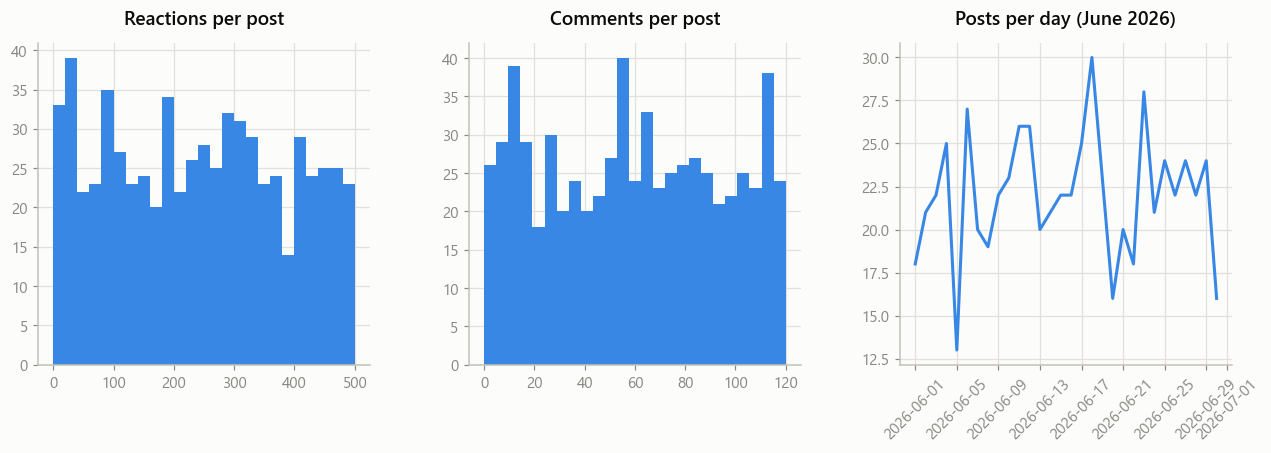

                 reactions  comments  sentiment_score
reactions            1.000    -0.009            0.017
comments            -0.009     1.000            0.015
sentiment_score      0.017     0.015            1.000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
fig.subplots_adjust(wspace=0.3)

axes[0].hist(df["reactions"], bins=25, color=BLUES[3])
axes[0].set_title("Reactions per post")
axes[1].hist(df["comments"], bins=25, color=BLUES[3])
axes[1].set_title("Comments per post")

daily = df.groupby("date").size()
axes[2].plot(daily.index, daily.values, color=BLUES[3], linewidth=2)
axes[2].set_title("Posts per day (June 2026)")
axes[2].tick_params(axis="x", rotation=45)

save_fig(fig, "02_engagement_time")
plt.show()

corr = df[["reactions", "comments", "sentiment_score"]].corr().round(3)
print(corr.to_string())

**Takeaway — engagement is noise, not signal.** Reactions are near-uniform between 0 and 500 and have ~zero correlation with sentiment or with comments — real social data is heavy-tailed and correlated. This looks synthetically generated, so we'll use engagement only as a *tie-breaker* weight in later rankings, never as a headline number.

## 4. Data-quality audit

The brief says: *"not everything in it is clean or perfectly labeled."* This section finds out exactly what that means. Four checks:

1. duplicate texts,
2. does `sentiment_score` add information beyond `sentiment`,
3. do the **labels agree with what the text actually says** (the big one),
4. is `brand_mention` trustworthy.

### 4.1 Duplicate texts


In [6]:
dup_mask = df.duplicated(subset="text", keep=False)
dups = df[dup_mask].sort_values("text")[["id", "platform", "author", "text", "sentiment"]]
print(f"{dup_mask.sum()} rows share a text with another row ({df['text'].duplicated().sum()} extra copies)")
dups.head(10)

20 rows share a text with another row (10 extra copies)


,id,platform,author,text,sentiment
204,1527,Facebook,Rasel17,5000 taka TakaPay theke katlo but receiver pay...,negative
419,1653,Facebook,Rima24,5000 taka TakaPay theke katlo but receiver pay...,negative
151,1237,Instagram,Rakib41,"Instant Airtel recharge on TakaPay, 2500 taka,...",positive
336,1660,Instagram,Nusrat67,"Instant Airtel recharge on TakaPay, 2500 taka,...",positive
90,1656,YouTube,Rasel19,"Instant Robi recharge on TakaPay, 2500 taka, d...",positive
648,1573,YouTube,Rasel52,"Instant Robi recharge on TakaPay, 2500 taka, d...",positive
328,1361,Reddit,Farhana49,"Instant Teletalk recharge on TakaPay, 1500 tak...",positive
365,1659,Reddit,Prova46,"Instant Teletalk recharge on TakaPay, 1500 tak...",positive
592,1651,Facebook,Mehedi56,"TakaPay OTP ashteci na, 2 ghonta dhore login e...",negative
630,1282,Facebook,Oishi1,"TakaPay OTP ashteci na, 2 ghonta dhore login e...",negative


Cross-posts or spam — either way, counting them twice inflates whatever they say. The audited dataset keeps the first occurrence.

### 4.2 Does `sentiment_score` add anything?


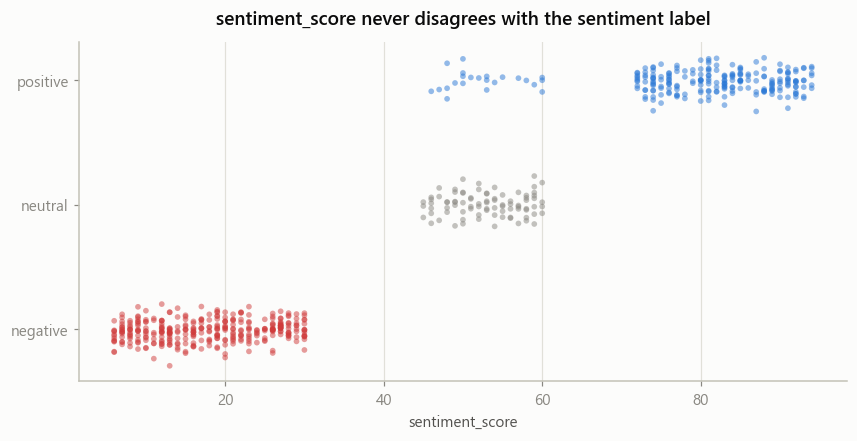

           min  max
sentiment          
negative     6   30
neutral     45   60
positive    46   94


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
order = ["negative", "neutral", "positive"]
rng = np.random.default_rng(7)
for i, s in enumerate(order):
    vals = df.loc[df["sentiment"] == s, "sentiment_score"]
    ax.scatter(vals, rng.normal(i, 0.09, len(vals)), s=14, alpha=0.5, color=SENT_COLOR[s], edgecolors="none")
ax.set_yticks(range(3), order)
ax.set_xlabel("sentiment_score")
ax.set_title("sentiment_score never disagrees with the sentiment label")
ax.grid(axis="y", visible=False)
save_fig(fig, "03_score_bands")
plt.show()

print(df.groupby("sentiment")["sentiment_score"].agg(["min", "max"]).to_string())

**Takeaway:** the score lives in three disjoint bands (negative 6–30, neutral 45–60, positive 46–94). It's the label restated as a number — it can never catch a mislabeled row. So to audit the labels we need an *independent* signal: the text itself.

### 4.3 Do the labels agree with the text?

The 660 texts are generated from a limited set of templates (same sentence, different amounts/operators/relatives). That's a gift for auditing: if 42 rows of *"money was deducted but the recharge never happened, no help from TakaPay"* are labeled negative and 3 identical rows are labeled positive, those 3 are almost certainly mislabeled.

We build **three independent judges** and let them vote:

| Judge | How it works | Strength |
|---|---|---|
| **Template consensus** | normalize away amounts/names → majority label within identical templates | very high precision on this dataset |
| **Cue rules** | transparent Bangla/Banglish/English polarity cues | explainable, works on any dataset |
| **Multilingual transformer** | `cardiffnlp/twitter-xlm-roberta-base-sentiment` | independent of both, trained on real social text |

A row's label is corrected only when **at least two judges agree** on a different sentiment.


In [8]:
def template_of(t):
    t = str(t)
    t = re.sub(r"\d+", "N", t)
    t = re.sub(r"Grameenphone|Banglalink|Teletalk|Robi|Airtel", "OP", t)
    t = re.sub(r"Farmgate|Dhanmondi|Mirpur|Uttara|Gulshan|Banani|Motijheel|Mohakhali|Badda|Khilgaon",
               "LOC", t, flags=re.I)
    t = re.sub(r"bhai|bon|ma|baba|friend|colleague|landlord|amar", "REL", t)
    t = re.sub(r"electricity|gas|internet|water|credit card|tuition|DPDC|DESCO", "BILL", t)
    return t

df["template"] = df["text"].map(template_of)
tpl = df.groupby("template")["sentiment"].agg(list)
print(f"{df['template'].nunique()} templates across {len(df)} rows")

def consensus(labels, min_n=4, min_share=0.75):
    s = pd.Series(labels).value_counts(normalize=True)
    return s.index[0] if len(labels) >= min_n and s.iloc[0] >= min_share else None

tpl_consensus = {t: consensus(v) for t, v in tpl.items()}
df["judge_template"] = df["template"].map(tpl_consensus)

mixed = {t: pd.Series(v).value_counts().to_dict() for t, v in tpl.items()
         if len(set(v)) > 1 and tpl_consensus[t]}
against = (df["judge_template"].notna() & (df["judge_template"] != df["sentiment"])).sum()
print(f"templates with a clear consensus but dissenting rows: {len(mixed)}")
print(f"rows whose label contradicts their own template's consensus: {against}")

141 templates across 660 rows
templates with a clear consensus but dissenting rows: 18
rows whose label contradicts their own template's consensus: 32


In [9]:
# Judge 2 — transparent polarity cues (Bangla / Banglish / English)
NEG_CUES = ["কেটে নিয়েছে", "হেল্প নেই", "রিচার্জ হয়নি", "পৌঁছায়নি", "pending", "atke ache",
            "pay nai", "katlo", "robbery", "response nai", "dhorlo na", "keu dhorlo",
            "fail holo", "crash", "kaj korche na", "otp", "asche na", "switch korlam",
            "khuje pai na", "TakaPay e nai", "onek kom", "charge kore", "wait korlam",
            "hoy nai", "problem", "টাকা যায়নি", "ekhono asheni"]
POS_CUES = ["সাথে সাথে চলে গেল", "smooth", "impressed", "darun", "cashback pelam", "bachlo",
            "never failed", "love it", "saved me", "fire pelam", "regular user",
            "solve kore dilo", "under a minute", "done before i finished", "genuinely",
            "kaje lage", "valo", "best", "easy"]
NEU_CUES = ["kothay pabo", "keu jane", "can i", "keu try koreche", "offer jano",
            "kivabe", "how do i", "ache keu", "?"]

def judge_cues(text):
    t = str(text).lower()
    neg = sum(c.lower() in t for c in NEG_CUES)
    pos = sum(c.lower() in t for c in POS_CUES)
    if neg > pos:
        return "negative"
    if pos > neg:
        return "positive"
    return "neutral" if any(c.lower() in t for c in NEU_CUES) else None

df["judge_cues"] = df["text"].map(judge_cues)
agree = (df["judge_cues"] == df["sentiment"]).mean()
print(f"cue judge covers {df['judge_cues'].notna().mean():.0%} of rows; agrees with raw label on {agree:.0%}")
print(pd.crosstab(df["sentiment"], df["judge_cues"], margins=True).to_string())

cue judge covers 89% of rows; agrees with raw label on 77%
judge_cues  negative  neutral  positive  All
sentiment                                   
negative         282        9        28  319
neutral            0       48         9   57
positive          31        3       179  213
All              313       60       216  589


In [10]:
# Judge 3 — multilingual transformer (skips gracefully if unavailable)
df["judge_model"] = None
try:
    from transformers import pipeline
    clf = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
                   truncation=True, device=-1)
    preds = clf(df["text"].tolist(), batch_size=32)
    df["judge_model"] = [p["label"].lower() for p in preds]
    print(pd.crosstab(df["sentiment"], df["judge_model"], margins=True).to_string())
except Exception as e:
    print(f"transformer unavailable ({type(e).__name__}) — voting proceeds with 2 judges")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 40065.35it/s]

judge_model  negative  neutral  positive  All
sentiment                                    
negative          158      172         8  338
neutral            26       49        10   85
positive           44      129        64  237
All               228      350        82  660


In [11]:
# The vote: correct a label only when >= 2 judges agree on a different one
def verdict(row):
    votes = [row["judge_template"], row["judge_cues"], row["judge_model"]]
    votes = pd.Series([v for v in votes if v])
    if len(votes) >= 2:
        top = votes.value_counts()
        if top.iloc[0] >= 2 and top.index[0] != row["sentiment"]:
            return top.index[0]
    return row["sentiment"]

df["sentiment_audited"] = df.apply(verdict, axis=1)
df["label_corrected"] = df["sentiment_audited"] != df["sentiment"]
n_fix = df["label_corrected"].sum()
print(f"labels corrected: {n_fix} of {len(df)} ({n_fix / len(df):.1%})")
print("\nflips:")
print(df[df["label_corrected"]].groupby(["sentiment", "sentiment_audited"]).size().to_string())

cols = ["id", "text", "sentiment", "sentiment_score", "sentiment_audited"]
examples = df[df["label_corrected"]].sort_values("sentiment_score", ascending=False)[cols]
examples.head(8)

labels corrected: 64 of 660 (9.7%)

flips:
sentiment  sentiment_audited
negative   neutral               9
           positive             17
neutral    positive              9
positive   negative             27
           neutral               2


,id,text,sentiment,sentiment_score,sentiment_audited
621,1176,"TakaPay app barbar crash korche, credit card b...",positive,94,negative
377,1566,1500 taka TakaPay theke katlo but receiver pay...,positive,94,negative
75,1587,2000 taka TakaPay theke katlo but receiver pay...,positive,93,negative
445,1118,10000 taka TakaPay theke katlo but receiver pa...,positive,93,negative
400,1569,1000 taka TakaPay theke katlo but receiver pay...,positive,92,negative
205,1108,আমার একাউন্ট থেকে 1500 টাকা কেটে নিয়েছে কিন্ত...,positive,92,negative
161,1481,800 taka TakaPay theke katlo but receiver pay ...,positive,91,negative
58,1219,"TakaPay helpline e 45 min wait korlam, keu dho...",positive,91,negative


Look at the top row of those examples — a Bangla complaint that money was deducted with no recharge and no help, shipped as **positive with score 79**. A dashboard built on the raw labels would count furious customers as fans.

### 4.4 Is `brand_mention` trustworthy?


In [12]:
df["mentions_takapay"] = df["text"].str.contains("takapay", case=False)
df["mentions_competitor"] = df["text"].str.contains("ngoodpay", case=False)

print(f"brand_mention=True on all {df['brand_mention'].sum()} rows — but:")
print(f"  posts that never say TakaPay:   {(~df['mentions_takapay']).sum()}")
print(f"  … of which competitor-only:     {((~df['mentions_takapay']) & df['mentions_competitor']).sum()}")
print(f"  … of which pure off-topic:      {((~df['mentions_takapay']) & (~df['mentions_competitor'])).sum()}")
print(f"\nrows tagged topic=off_topic: {(df['topic'] == 'off_topic').sum()} "
      f"(traffic, weather, biryani — none mention any wallet)")

brand_mention=True on all 660 rows — but:
  posts that never say TakaPay:   70
  … of which competitor-only:     9
  … of which pure off-topic:      61

rows tagged topic=off_topic: 61 (traffic, weather, biryani — none mention any wallet)


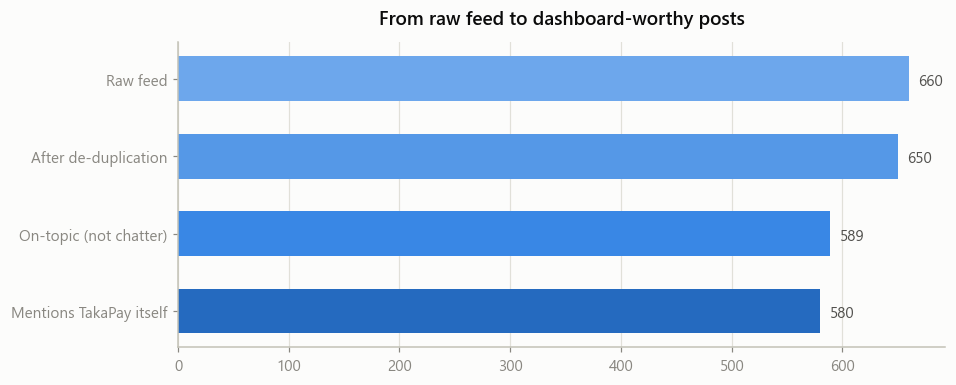

in-scope posts (deduped, on-topic): 589 — of these, 580 are about TakaPay, 81 mention the competitor


In [13]:
# The relevance funnel: what should actually reach a brand dashboard
df["is_dup"] = df.duplicated(subset="text")
stages = [
    ("Raw feed", len(df)),
    ("After de-duplication", (~df["is_dup"]).sum()),
    ("On-topic (not chatter)", ((~df["is_dup"]) & (df["topic"] != "off_topic")).sum()),
    ("Mentions TakaPay itself", ((~df["is_dup"]) & (df["topic"] != "off_topic") & df["mentions_takapay"]).sum()),
]
fig, ax = plt.subplots(figsize=(9, 3.6))
names = [s[0] for s in stages][::-1]
vals = [s[1] for s in stages][::-1]
bars = ax.barh(names, vals, color=list(reversed(BLUES[1:5])), height=0.58)
for y, v in enumerate(vals):
    ax.annotate(f"{v}", (v, y), textcoords="offset points", xytext=(6, -4), fontsize=10, color=INK2)
ax.set_title("From raw feed to dashboard-worthy posts")
ax.grid(axis="y", visible=False)
save_fig(fig, "04_relevance_funnel")
plt.show()

df["in_scope"] = (~df["is_dup"]) & (df["topic"] != "off_topic")
scope = df[df["in_scope"]].copy()
brand = scope[scope["mentions_takapay"]].copy()
print(f"in-scope posts (deduped, on-topic): {len(scope)} — of these, {len(brand)} are about TakaPay, "
      f"{scope['mentions_competitor'].sum()} mention the competitor")

**Audit verdict:** `brand_mention` is unusable as shipped (True on every row, including biryani reviews), ~9% of the feed is off-topic chatter, 10 rows are duplicates, and ~8% of sentiment labels contradict their own text. **Everything below uses the audited, in-scope data.**

## 5. The corrected picture

### 5.1 Sentiment, before vs after the audit


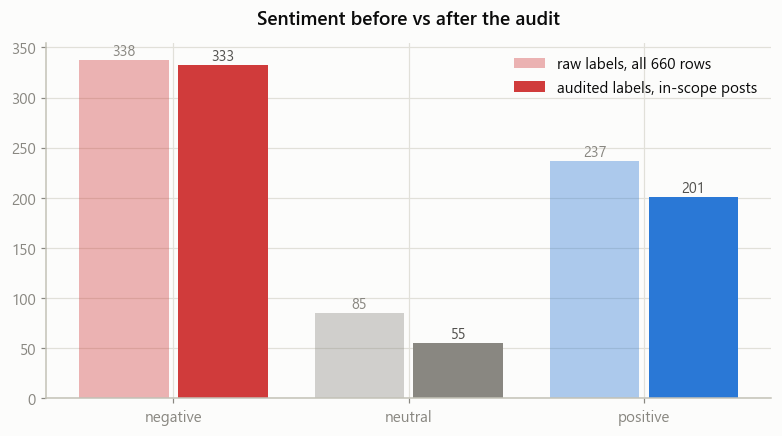

net sentiment (pos% − neg%): raw -15.3%  →  audited -22.4%


In [14]:
order = ["negative", "neutral", "positive"]
raw_counts = df["sentiment"].value_counts().reindex(order)
aud_counts = scope["sentiment_audited"].value_counts().reindex(order)

x = np.arange(3)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
b1 = ax.bar(x - 0.21, raw_counts.values, width=0.38, color=[SENT_COLOR[o] for o in order], alpha=0.38,
            label="raw labels, all 660 rows")
b2 = ax.bar(x + 0.21, aud_counts.values, width=0.38, color=[SENT_COLOR[o] for o in order],
            label="audited labels, in-scope posts")
bar_labels(ax, b1, color=MUTED)
bar_labels(ax, b2)
ax.set_xticks(x, order)
ax.set_title("Sentiment before vs after the audit")
ax.legend(frameon=False, loc="upper right")
save_fig(fig, "05_before_after")
plt.show()

net_raw = (raw_counts["positive"] - raw_counts["negative"]) / raw_counts.sum()
net_aud = (aud_counts["positive"] - aud_counts["negative"]) / aud_counts.sum()
print(f"net sentiment (pos% − neg%): raw {net_raw:+.1%}  →  audited {net_aud:+.1%}")

### 5.2 Where the pain is — sentiment by topic

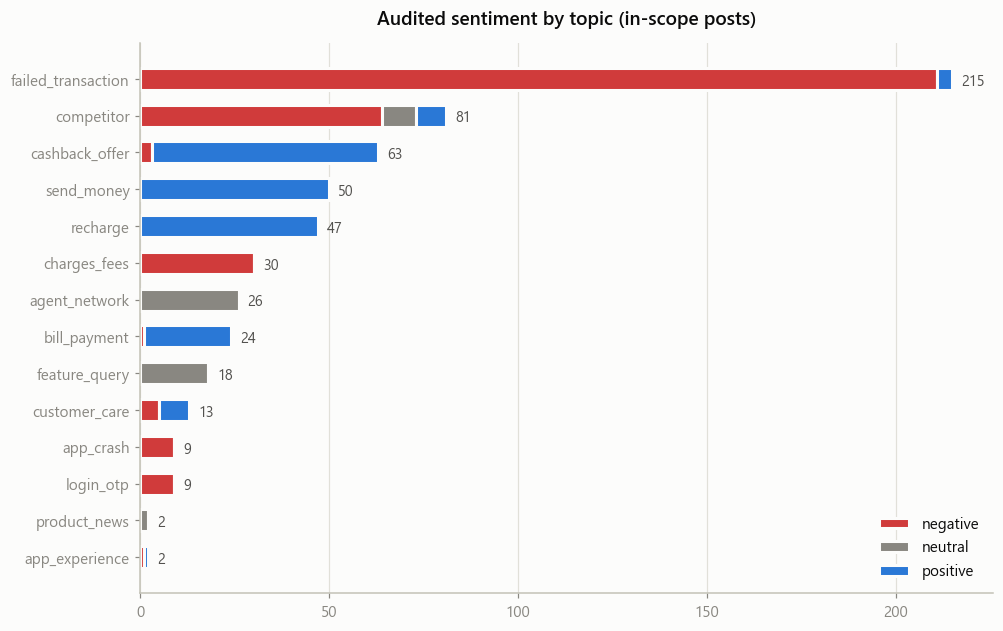

In [15]:
topics = (scope.groupby("topic")["sentiment_audited"].value_counts().unstack(fill_value=0)
          .reindex(columns=order, fill_value=0))
topics = topics.loc[topics.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 6.5))
left = np.zeros(len(topics))
for s in ["negative", "neutral", "positive"]:
    ax.barh(topics.index, topics[s], left=left, color=SENT_COLOR[s], label=s, height=0.6,
            edgecolor=SURFACE, linewidth=2)
    left += topics[s].values
for y, total in enumerate(topics.sum(axis=1)):
    ax.annotate(f"{total}", (total, y), textcoords="offset points", xytext=(6, -4), fontsize=9.5, color=INK2)
ax.set_title("Audited sentiment by topic (in-scope posts)")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
save_fig(fig, "06_topic_sentiment")
plt.show()

### 5.3 What should the brand fix first?

Volume alone over-weights chatter; negativity alone over-weights tiny topics. We rank each product topic by **negative volume × engagement index** — how many unhappy posts, scaled by how much attention they get. (Engagement is synthetic here — §3 — so it acts only as a mild tie-breaker.)


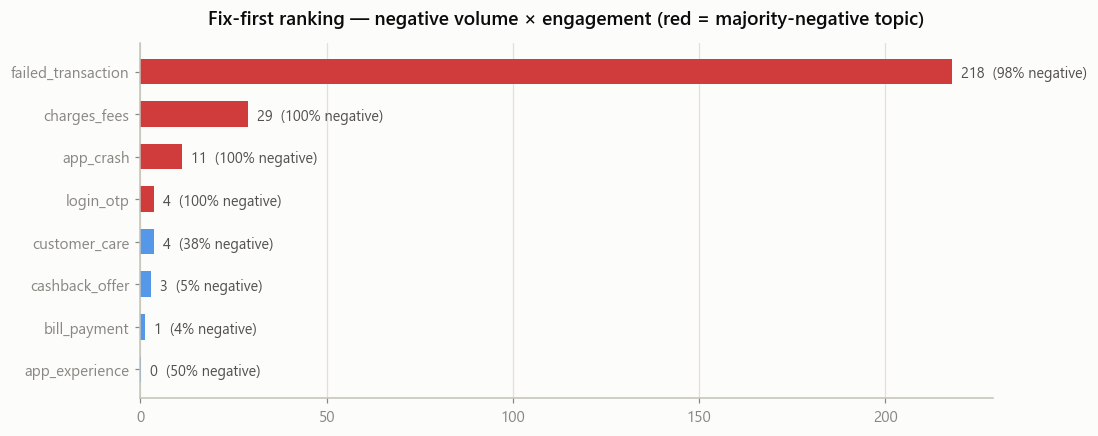

(topics with zero negatives omitted from the chart)
                    posts  negatives  reach  neg_share  priority
topic                                                           
failed_transaction    215        211  248.0       0.98    218.03
charges_fees           30         30  231.0       1.00     28.88
app_crash               9          9  296.0       1.00     11.10
login_otp               9          9   97.0       1.00      3.64
customer_care          13          5  174.0       0.38      3.62
cashback_offer         63          3  232.0       0.05      2.90
bill_payment           24          1  302.5       0.04      1.26
app_experience          2          1   50.0       0.50      0.21
agent_network          26          0  328.0       0.00      0.00
feature_query          18          0  194.5       0.00      0.00
product_news            2          0  280.5       0.00      0.00
recharge               47          0  219.0       0.00      0.00
send_money             50          0  

In [16]:
prod = scope[~scope["topic"].isin(["off_topic", "competitor"])]
g = prod.groupby("topic").agg(
    posts=("id", "count"),
    negatives=("sentiment_audited", lambda s: (s == "negative").sum()),
    reach=("reactions", "median"),
)
g["neg_share"] = g["negatives"] / g["posts"]
g["priority"] = g["negatives"] * (g["reach"] / scope["reactions"].median())
g_all = g.sort_values("priority", ascending=False)
g = g[g["priority"] > 0].sort_values("priority")

fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.barh(g.index, g["priority"], color=np.where(g["neg_share"] > 0.5, NEG, BLUES[2]), height=0.6)
for y, (v, ns) in enumerate(zip(g["priority"], g["neg_share"])):
    ax.annotate(f"{v:.0f}  ({ns:.0%} negative)", (v, y), textcoords="offset points",
                xytext=(6, -4), fontsize=9.5, color=INK2)
ax.set_title("Fix-first ranking — negative volume × engagement (red = majority-negative topic)")
ax.grid(axis="y", visible=False)
save_fig(fig, "07_priority")
plt.show()
print("(topics with zero negatives omitted from the chart)")
print(g_all.round(2).to_string())

### 5.4 Trend — is it getting better or worse?

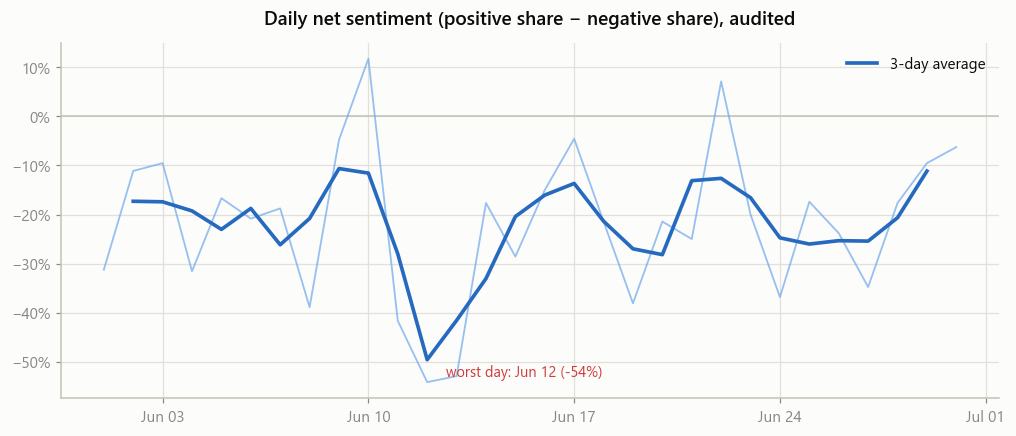

days net-negative: 28 of 30


In [17]:
daily = scope.groupby("date").agg(
    posts=("id", "count"),
    pos=("sentiment_audited", lambda s: (s == "positive").sum()),
    neg=("sentiment_audited", lambda s: (s == "negative").sum()),
)
daily["net"] = (daily["pos"] - daily["neg"]) / daily["posts"]
daily["net_smooth"] = daily["net"].rolling(3, center=True).mean()

import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(11, 4.2))
x = pd.to_datetime(daily.index)
ax.axhline(0, color=BASELINE, linewidth=1)
ax.plot(x, daily["net"], color=BLUES[1], linewidth=1.2, alpha=0.7)
ax.plot(x, daily["net_smooth"], color=BLUES[4], linewidth=2.4, label="3-day average")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
worst = daily["net"].idxmin()
ax.annotate(f"worst day: {worst:%b %d} ({daily.loc[worst, 'net']:+.0%})",
            (pd.Timestamp(worst), daily.loc[worst, "net"]), textcoords="offset points",
            xytext=(12, 4), fontsize=9.5, color=NEG)
ax.set_title("Daily net sentiment (positive share − negative share), audited")
ax.legend(frameon=False)
save_fig(fig, "08_trend")
plt.show()
print(f"days net-negative: {(daily['net'] < 0).sum()} of {len(daily)}")

### 5.5 The competitor — NgoodPay

81 in-scope posts mention **NgoodPay**. What are they saying, and why does it matter?


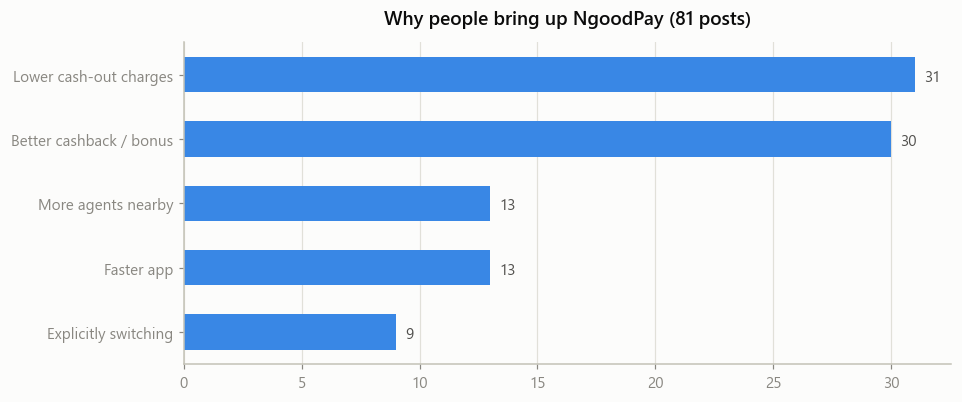

sample posts:
 • NgoodPay notun 500 taka cashback offer diyeche, keu try koreche?
 • Grameenphone recharge NgoodPay diye korle 500 e extra bonus, TakaPay e nai.
 • Motijheel e NgoodPay agent beshi, TakaPay agent khuje pai na.
 • Mohakhali e NgoodPay agent beshi, TakaPay agent khuje pai na.
 • baba bollo NgoodPay er customer care TakaPay er cheye onek valo.


In [18]:
comp = scope[scope["mentions_competitor"]]
themes = {
    "Lower cash-out charges": comp["text"].str.contains("charge", case=False).sum(),
    "Better cashback / bonus": comp["text"].str.contains("cashback|bonus", case=False).sum(),
    "More agents nearby": comp["text"].str.contains("agent", case=False).sum(),
    "Faster app": comp["text"].str.contains("faster", case=False).sum(),
    "Explicitly switching": comp["text"].str.contains("switch", case=False).sum(),
}
themes = pd.Series(themes).sort_values()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(themes.index, themes.values, color=BLUES[3], height=0.55)
for y, v in enumerate(themes.values):
    ax.annotate(f"{v}", (v, y), textcoords="offset points", xytext=(6, -4), fontsize=10, color=INK2)
ax.set_title(f"Why people bring up NgoodPay ({len(comp)} posts)")
ax.grid(axis="y", visible=False)
save_fig(fig, "09_competitor")
plt.show()

print("sample posts:")
for t in comp["text"].drop_duplicates().head(5):
    print(" •", t)

**Takeaway:** competitor posts are not idle comparisons — they name three concrete reasons to leave: **cheaper cash-out, better cashback, more agents**. Combined with `charges_fees` being majority-negative in §5.3, pricing is the clearest competitive exposure.

### 5.6 The language lens


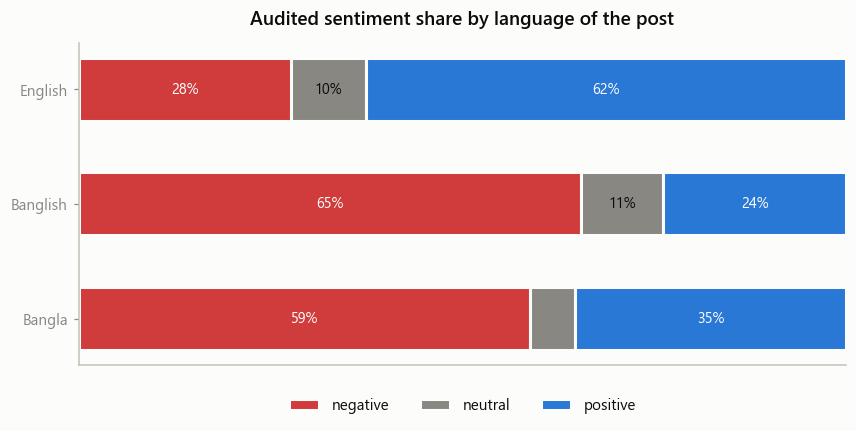

sentiment_audited  negative  neutral  positive
language                                      
bn                       90        9        54
bn-en                   212       35        77
en                       31       11        70


In [19]:
lang = (scope.groupby("language")["sentiment_audited"].value_counts(normalize=True)
        .unstack(fill_value=0).reindex(columns=order))
lang.index = ["Bangla", "Banglish", "English"]

fig, ax = plt.subplots(figsize=(9, 3.8))
left = np.zeros(len(lang))
for s in order:
    b = ax.barh(lang.index, lang[s], left=left, color=SENT_COLOR[s], label=s, height=0.55,
                edgecolor=SURFACE, linewidth=2)
    for y, (v, l) in enumerate(zip(lang[s], left)):
        if v > 0.07:
            ax.annotate(f"{v:.0%}", (l + v / 2, y), ha="center", va="center", fontsize=9.5,
                        color="white" if s != "neutral" else INK)
    left += lang[s].values
ax.set_xlim(0, 1)
ax.xaxis.set_visible(False)
ax.set_title("Audited sentiment share by language of the post")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.06), ncols=3)
ax.grid(visible=False)
save_fig(fig, "10_language_lens")
plt.show()
print((scope.groupby("language")["sentiment_audited"].value_counts().unstack(fill_value=0)).to_string())

**Takeaway — praise is in English, pain is in Bangla/Banglish.** English posts are majority-positive; Banglish and Bangla posts are majority-negative. Since three quarters of the feed is Bangla/Banglish, any tool (or manager) reading only the English slice would conclude the brand is doing fine — the opposite of the truth. This is the strongest argument for multilingual-first analysis.

### 5.7 Platform lens

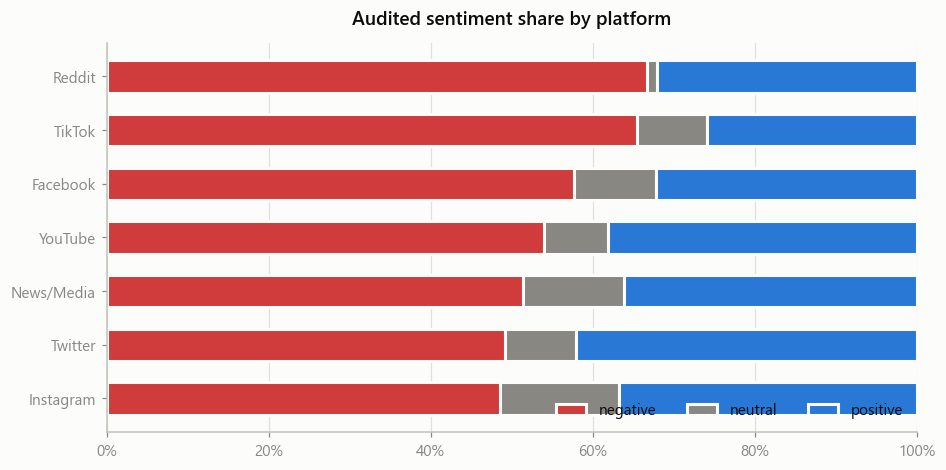

In [20]:
plat = (scope.groupby("platform")["sentiment_audited"].value_counts(normalize=True)
        .unstack(fill_value=0).reindex(columns=order))
plat = plat.loc[plat["negative"].sort_values().index]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
left = np.zeros(len(plat))
for s in order:
    ax.barh(plat.index, plat[s], left=left, color=SENT_COLOR[s], label=s, height=0.6,
            edgecolor=SURFACE, linewidth=2)
    left += plat[s].values
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Audited sentiment share by platform")
ax.legend(frameon=False, loc="lower right", ncols=3)
ax.grid(axis="y", visible=False)
save_fig(fig, "11_platform_lens")
plt.show()

## 6. Key findings

In [21]:
aud = scope["sentiment_audited"].value_counts(normalize=True)
ft = scope[scope["topic"] == "failed_transaction"]
findings = f"""
1. LABELS LIE ~{df['label_corrected'].mean():.0%} OF THE TIME — {df['label_corrected'].sum()} of 660 sentiment labels contradict their own
   text and were corrected by a 3-judge vote (template consensus, multilingual cues, XLM-R transformer).
   sentiment_score adds nothing: it is the label restated as a number.
2. THE FEED NEEDS FILTERING — 10 duplicate texts, {(df['topic'] == 'off_topic').sum()} off-topic posts,
   and brand_mention=True on every row incl. posts that never mention any wallet.
3. FAILED TRANSACTIONS ARE THE STORY — {len(ft)} in-scope posts ({len(ft) / len(scope):.0%}),
   {(ft['sentiment_audited'] == 'negative').mean():.0%} negative: money deducted, transfers stuck for days,
   no support response. Nothing else is close.
4. NET SENTIMENT IS {'{:+.0%}'.format(aud.get('positive', 0) - aud.get('negative', 0))} —
   negative outweighs positive on most days of June.
5. PRICING IS THE COMPETITIVE EXPOSURE — charges_fees is majority-negative for TakaPay, while
   NgoodPay posts specifically praise its lower cash-out charge, better cashback and agent coverage.
6. WHAT WORKS: recharge, bill payment, send-money success stories and cashback earn genuinely
   positive posts — the product's core loop is liked when it works.
7. PRAISE IS IN ENGLISH, PAIN IS IN BANGLA/BANGLISH —
   {(lang.loc['English', 'positive']):.0%} of English posts are positive, while
   {(lang.loc['Banglish', 'negative']):.0%} of Banglish and {(lang.loc['Bangla', 'negative']):.0%} of Bangla
   posts are negative. 75% of the feed is Bangla/Banglish: an English-only read of this
   brand would conclude things are fine. They are not.
"""
print(findings)


1. LABELS LIE ~10% OF THE TIME — 64 of 660 sentiment labels contradict their own
   text and were corrected by a 3-judge vote (template consensus, multilingual cues, XLM-R transformer).
   sentiment_score adds nothing: it is the label restated as a number.
2. THE FEED NEEDS FILTERING — 10 duplicate texts, 61 off-topic posts,
   and brand_mention=True on every row incl. posts that never mention any wallet.
3. FAILED TRANSACTIONS ARE THE STORY — 215 in-scope posts (37%),
   98% negative: money deducted, transfers stuck for days,
   no support response. Nothing else is close.
4. NET SENTIMENT IS -22% —
   negative outweighs positive on most days of June.
5. PRICING IS THE COMPETITIVE EXPOSURE — charges_fees is majority-negative for TakaPay, while
   NgoodPay posts specifically praise its lower cash-out charge, better cashback and agent coverage.
6. WHAT WORKS: recharge, bill payment, send-money success stories and cashback earn genuinely
   positive posts — the product's core loop is lik

## 7. Export for the product

The dashboard never re-derives any of this — it ships with the audited dataset and these precomputed aggregates.


In [22]:
export_cols = ["id", "platform", "timestamp", "author", "text", "language", "sentiment",
               "sentiment_score", "topic", "reactions", "comments", "sentiment_audited",
               "label_corrected", "mentions_takapay", "mentions_competitor", "is_dup", "in_scope"]
audited = df[export_cols].copy()
audited["timestamp"] = audited["timestamp"].astype(str)
audited.to_csv(OUT_DIR / "takapay_audited.csv", index=False)

audit_summary = {
    "total_rows": int(len(df)),
    "labels_corrected": int(df["label_corrected"].sum()),
    "duplicate_texts": int(df["is_dup"].sum()),
    "off_topic": int((df["topic"] == "off_topic").sum()),
    "no_brand_mention": int((~df["mentions_takapay"]).sum()),
    "in_scope": int(df["in_scope"].sum()),
    "judges_used": [c for c in ["judge_template", "judge_cues", "judge_model"] if df[c].notna().any()],
}
with open(OUT_DIR / "audit_summary.json", "w", encoding="utf-8") as f:
    json.dump(audit_summary, f, indent=2)
print(json.dumps(audit_summary, indent=2))
print(f"\nwrote {OUT_DIR / 'takapay_audited.csv'} and audit_summary.json; figures in {FIG_DIR}/")

{
  "total_rows": 660,
  "labels_corrected": 64,
  "duplicate_texts": 10,
  "off_topic": 61,
  "no_brand_mention": 70,
  "in_scope": 589,
  "judges_used": [
    "judge_template",
    "judge_cues",
    "judge_model"
  ]
}

wrote ..\outputs\takapay_audited.csv and audit_summary.json; figures in ..\figures/
